# Vega en Hull–White: Pathwise vs. Diferencias Finitas

**Objetivo del notebook.** Estimar la Vega de una opción europea bajo Hull–White respecto a la volatilidad del subyacente $\sigma_S$ por dos métodos Monte Carlo:

1. **Diferencias Finitas centradas (FD)** con *common random numbers* (CRN).
2. **Pathwise (PW)**, extendiendo el estimador del capítulo Black–Scholes al entorno de descuento estocástico.

Bajo log-Euler la derivada $\partial \ln S_T / \partial \sigma_S = W_T^S - \sigma_S T$ se conserva (el drift estocástico $r_{t_k}$ no depende de $\sigma_S$), de modo que

$$
\widehat{\mathcal{V}}_{\sigma_S}^{\,PW} \;=\; \frac{1}{N}\sum_{n=1}^{N} D^{(n)}\,\mathbf{1}_{\{S_T^{(n)} > K\}}\,S_T^{(n)}\,\bigl(W_T^{S,(n)} - \sigma_S T\bigr).
$$

El browniano terminal $W_T^{S,(n)}$ no se guarda durante la simulación, pero se reconstruye desde la trayectoria del subyacente invirtiendo el esquema log-Euler:

$$
\Delta W_k^{S,(n)} \;=\; \frac{1}{\sigma_S}\!\left[ \ln\!\frac{S_{t_{k+1}}^{(n)}}{S_{t_k}^{(n)}} - \Bigl(r_{t_k}^{(n)} - \tfrac{1}{2}\sigma_S^2\Bigr)\Delta t \right].

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hullwhite import GeneratePathsHWAndAssetEuler, P0T, PriceEuropeanOptionHWMC

np.set_printoptions(suppress=True, precision=6)

## 1. Parámetros del experimento

Parámetros estándar del Cap. 4.

In [2]:
S0        = 100.0
K         = 100.0
sigma_S   = 0.20
lambd     = 0.5
eta       = 0.01
rho       = -0.3
T         = 1.0
N         = 20_000
M         = 250
SEED      = 3

## 2. Estimadores

**FD.** Reutiliza directamente `PriceEuropeanOptionHWMC` evaluado en $\sigma_S \pm h$ con la misma semilla (CRN).

**Pathwise.** Adicionalmente reconstruye $W_T^{S,(n)}$ desde las trayectorias $(R^{(n)}, S^{(n)})$ generadas.

In [3]:
def VegaFD_HW_MC(NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
                 S0, sigma_S, rho, K, h=0.01,
                 option_type="call", seed=SEED):
    """
    Vega por diferencias finitas centradas con common random numbers.
    Perturbacion sobre sigma_S; el resto de parámetros se mantiene fijo.
    """
    paths_up = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
        S0, sigma_S + h, rho, seed=seed)
    V_up, _ = PriceEuropeanOptionHWMC(paths_up, K, T, option_type)

    paths_dn = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
        S0, sigma_S - h, rho, seed=seed)
    V_dn, _ = PriceEuropeanOptionHWMC(paths_dn, K, T, option_type)

    return (V_up - V_dn) / (2.0 * h)

In [4]:
def VegaPathwise_HW_MC(NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
                       S0, sigma_S, rho, K,
                       option_type="call", seed=SEED):
    """
    Vega pathwise en Hull-White.
        V_sigma_S = E[ D * 1_{S_T > K} * S_T * (W_T^S - sigma_S * T) ]
    El browniano W_T^S se reconstruye desde la trayectoria (S, R)
    invirtiendo el esquema log-Euler.
    """
    paths = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
        S0, sigma_S, rho, seed=seed)

    R = paths["R"]
    S = paths["S"]
    dt = T / NoOfSteps

    # Reconstruccion de los incrementos brownianos del subyacente
    log_increments = np.log(S[:, 1:] / S[:, :-1])
    drift_terms    = (R[:, :-1] - 0.5 * sigma_S**2) * dt
    dW_S           = (log_increments - drift_terms) / sigma_S
    W_T_S          = dW_S.sum(axis=1)

    # Factor de descuento estocastico
    integral_r = np.sum(R[:, :-1] * dt, axis=1)
    D          = np.exp(-integral_r)
    ST         = S[:, -1]

    if option_type.lower() == "call":
        indicator = (ST > K).astype(float)
    elif option_type.lower() == "put":
        indicator = -(ST < K).astype(float)
    else:
        raise ValueError("option_type debe ser 'call' o 'put'.")

    pw_realizations = D * indicator * ST * (W_T_S - sigma_S * T)
    vega_pw         = np.mean(pw_realizations)
    se_pw           = np.std(pw_realizations, ddof=1) / np.sqrt(NoOfPaths)

    return vega_pw, se_pw

**Verificación de la reconstrucción de $W_T^S$.** Bajo $\mathbb{Q}$, $W_T^S \sim \mathcal{N}(0, T)$. Una comprobación elemental sobre la muestra simulada permite descartar errores en la reconstrucción del browniano terminal.

In [5]:
paths = GeneratePathsHWAndAssetEuler(
    N, M, T, P0T, lambd, eta, S0, sigma_S, rho, seed=SEED)
R = paths["R"]
S = paths["S"]
dt = T / M

log_increments = np.log(S[:, 1:] / S[:, :-1])
drift_terms    = (R[:, :-1] - 0.5 * sigma_S**2) * dt
W_T_S          = ((log_increments - drift_terms) / sigma_S).sum(axis=1)

print(f"Media muestral de W_T^S : {W_T_S.mean():+.4f}  (teórica: 0)")
print(f"Varianza muestral       : {W_T_S.var():.4f}  (teórica: {T})")

Media muestral de W_T^S : -0.0092  (teórica: 0)
Varianza muestral       : 0.9971  (teórica: 1.0)


## 3. Estimación puntual

Se compara con $h = 0{,}01$, equivalente a una perturbación relativa del $5\%$ sobre $\sigma_S = 0{,}20$.

In [7]:
h = 0.01

vega_fd = VegaFD_HW_MC(N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
                       h=h, option_type="call", seed=SEED)

vega_pw, se_pw = VegaPathwise_HW_MC(N, M, T, P0T, lambd, eta,
                                    S0, sigma_S, rho, K,
                                    option_type="call", seed=SEED)

print(f"Vega FD (h = {h})  = {vega_fd:.6f}")
print(f"Vega Pathwise     = {vega_pw:.6f}   (SE = {se_pw:.6f})")
print(f"|FD - PW|          = {abs(vega_fd - vega_pw):.6f}")

Vega FD (h = 0.01)  = 36.923342
Vega Pathwise     = 36.921737   (SE = 0.530433)
|FD - PW|          = 0.001606


La diferencia entre ambos estimadores es del orden del error estándar del estimador Pathwise. La extensión del esquema a Hull–White se ha reducido a (i) sustituir el descuento determinista por $D^{(n)}$ y (ii) reconstruir el browniano terminal desde las trayectorias simuladas, sin alterar la estructura teórica del estimador establecida en el capítulo de Black–Scholes.

## 4. Comparación de varianzas: FD vs. Pathwise

Para comparar la eficiencia de ambos métodos se repite la estimación de Vega sobre $n_{\text{rep}}$ simulaciones independientes (semillas distintas) manteniendo $N$ fijo. La desviación típica muestral de los $n_{\text{rep}}$ estimadores aproxima el error estándar de un estimador individual, y su cociente cuantifica la varianza relativa de FD con CRN frente a Pathwise.


In [8]:
# Repeticiones independientes para estimar la varianza de cada estimador
n_rep     = 60
base_seed = 1000   # semillas 1000, 1001, ... (distintas entre repeticiones)

def VegaRepeticiones_HW(n_rep, base_seed, h=0.01):
    """
    Repite la estimacion de Vega (respecto a sigma_S) sobre n_rep simulaciones
    independientes a N fijo. La desviacion tipica muestral sobre las repeticiones
    estima el error estandar de un estimador individual. Dentro de cada
    repeticion, FD emplea CRN (misma semilla en sigma_S+h y sigma_S-h).
    """
    fd = np.empty(n_rep)
    pw = np.empty(n_rep)
    for j in range(n_rep):
        s = base_seed + j
        fd[j] = VegaFD_HW_MC(N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
                             h=h, option_type="call", seed=s)
        pw[j], _ = VegaPathwise_HW_MC(N, M, T, P0T, lambd, eta,
                                      S0, sigma_S, rho, K,
                                      option_type="call", seed=s)
    return fd, pw

fd_rep, pw_rep = VegaRepeticiones_HW(n_rep, base_seed, h=0.01)

df_var = pd.DataFrame({
    "Metodo":    ["Diferencias finitas (CRN)", "Pathwise"],
    "Media":     [fd_rep.mean(), pw_rep.mean()],
    "SE (rep.)": [fd_rep.std(ddof=1), pw_rep.std(ddof=1)],
})

ratio = fd_rep.var(ddof=1) / pw_rep.var(ddof=1)
print(f"Repeticiones: {n_rep}   (N = {N}, M = {M})")
print(f"Cociente de varianzas FD/PW: {ratio:.4f}")
df_var.round(6)

Repeticiones: 60   (N = 20000, M = 250)
Cociente de varianzas FD/PW: 0.9988


,Metodo,Media,SE (rep.)
0,Diferencias finitas (CRN),37.481450,0.517462
1,Pathwise,37.483558,0.517761


Al igual que en Delta, los errores estándar de FD y Pathwise resultan prácticamente iguales (cociente de varianzas $\approx 1{,}00$). La perturbación de $\sigma_S$ con CRN preserva las trayectorias del tipo corto y el factor de descuento, de modo que la diferencia $V(\sigma_S+h)-V(\sigma_S-h)$ no introduce varianza adicional apreciable respecto al estimador pathwise. La elección entre métodos para esta griega responde de nuevo a criterios estructurales y no de eficiencia.


## 5. Sensibilidad del estimador FD respecto a $h$

Barrido sobre $h$ con el estimador Pathwise como referencia horizontal. El rango se selecciona dentro de $h \ll \sigma_S$ para evitar valores no admisibles ($\sigma_S - h \le 0$).

In [9]:
h_grid = np.array([0.1, 0.05, 0.02, 0.01, 0.005, 0.001, 0.0005, 0.0001])

results = []
for h in h_grid:
    v_fd = VegaFD_HW_MC(N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
                        h=h, option_type="call", seed=SEED)
    results.append({"h": h, "Vega_FD": v_fd, "|FD - PW|": abs(v_fd - vega_pw)})

df_h = pd.DataFrame(results)
df_h

,h,Vega_FD,|FD - PW|
0,0.1000,36.500197,0.421539
1,0.0500,36.830060,0.091676
2,0.0200,36.916383,0.005354
3,0.0100,36.923342,0.001606
4,0.0050,36.920479,0.001258
5,0.0010,36.920487,0.001250
6,0.0005,36.922962,0.001225
7,0.0001,36.921790,0.000053


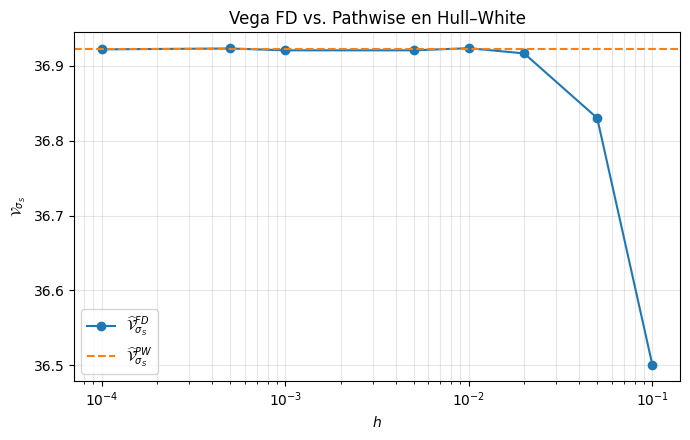

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogx(df_h["h"], df_h["Vega_FD"], marker="o", label=r"$\widehat{\mathcal{V}}_{\sigma_S}^{FD}$")
ax.axhline(vega_pw, color="C1", linestyle="--", label=r"$\widehat{\mathcal{V}}_{\sigma_S}^{PW}$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\mathcal{V}_{\sigma_S}$")
ax.set_title(r"Vega FD vs. Pathwise en Hull–White")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

**Observaciones.**

1. **PW.** Estimador estructuralmente independiente de $h$.
2. **FD.** Sesgo $\mathcal{O}(h^2)$ visible en $h = 0{,}10$ y $h = 0{,}05$; para $h \le 0{,}02$ el estimador queda dentro de la banda del error Monte Carlo del PW.
3. Para $h$ muy pequeño el estimador FD permanece estable: el uso de CRN preserva las mismas trayectorias del tipo corto en las dos simulaciones, evitando que la diferencia $V(\sigma_S+h) - V(\sigma_S-h)$ se vea dominada por ruido.

## 6. Conclusiones

1. La estructura del estimador Pathwise para Vega ---derivada en el capítulo Black–Scholes--- se conserva al pasar a Hull–White: el drift estocástico $r_{t_k}$ no depende de $\sigma_S$, y el factor de descuento entra como peso multiplicativo.
2. La única novedad de implementación es la reconstrucción del browniano terminal $W_T^{S,(n)}$ a partir de la trayectoria simulada.
3. Cuantitativamente, FD con CRN y PW coinciden hasta el error Monte Carlo, replicando el comportamiento observado para Delta (Notebook `delta_hw`).